
## Futbol Jugadores · Analítica de Datos I · Parcial 1
Freddy Trochez A00411060



---
## 1. Preparación del entorno

Cargamos las librerías que vamos a necesitar para trabajar con el dataset de futbol.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   Seaborn  : {sns.__version__}")

✅ Librerías cargadas correctamente
   Pandas   : 3.0.5
   NumPy    : 2.5.2
   Seaborn  : 0.13.2


---
## 2. Carga y verificación del dataset

Leemos el archivo de futbol que usaremos en esta parte.

📎 `dataset_futbol_jugadores.csv`

In [3]:
df = pd.read_csv("dataset_futbol_jugadores.csv")

for col in [
    "Asistencias", "Tarjetas_Amarillas", "Tarjetas_Rojas", "Valor_Mercado_Millones_EUR"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Asistencias"] = df["Asistencias"].fillna(0)
df["Tarjetas_Amarillas"] = df["Tarjetas_Amarillas"].fillna(0)
df["Tarjetas_Rojas"] = df["Tarjetas_Rojas"].fillna(0)
df["Valor_Mercado_Millones_EUR"] = df["Valor_Mercado_Millones_EUR"].fillna(
    df["Valor_Mercado_Millones_EUR"].median()
)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (150, 16)


,ID,Jugador,Equipo,Posicion,Nacionalidad,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
0,1,Jugador_001,Tigres SC,Mediocampista,Inglaterra,17,25,1,2.0,1125,2,0,171,76,6.03,5.12
1,2,Jugador_002,Aguilas FC,Portero,Chile,23,18,0,3.0,846,3,0,180,85,6.28,1.48
2,3,Jugador_003,Tigres SC,Defensa,Argentina,28,0,1,2.0,0,2,0,179,74,7.01,4.40
3,4,Jugador_004,Halcones CF,Defensa,Argentina,30,35,4,2.0,2695,3,0,182,74,7.36,4.15
4,5,Jugador_005,Aguilas FC,Defensa,Italia,35,14,2,3.0,840,3,0,170,75,6.17,2.31


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          150 non-null    int64  
 1   Jugador                     150 non-null    str    
 2   Equipo                      150 non-null    str    
 3   Posicion                    150 non-null    str    
 4   Nacionalidad                147 non-null    str    
 5   Edad                        150 non-null    int64  
 6   Partidos_Jugados            150 non-null    int64  
 7   Goles                       150 non-null    int64  
 8   Asistencias                 150 non-null    float64
 9   Minutos_Jugados             150 non-null    int64  
 10  Tarjetas_Amarillas          150 non-null    int64  
 11  Tarjetas_Rojas              150 non-null    int64  
 12  Altura_cm                   150 non-null    int64  
 13  Peso_kg                     150 non-null    in

In [13]:
faltantes = df.isna().sum()
porcentaje = (df.isna().mean() * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje
})

resumen_faltantes[resumen_faltantes["faltantes"] > 0]

,faltantes,porcentaje
Nacionalidad,3,2.00
Asistencias,9,6.00
Rating_Promedio,5,3.33
Valor_Mercado_Millones_EUR,6,4.00


El dataset en total tiene 23 valores nulos

La columna asistencia tiene 9 valores nulos

### 🔎 Chequeo rápido


In [14]:
for var in ["Posicion", "Equipo", "Nacionalidad"]:
    n = df[var].nunique()
    print(f"{var:20s} → {n:2d} valores únicos: {sorted(df[var].dropna().unique().tolist())}")

df["Posicion"] = df["Posicion"].str.strip().str.title()
df["Equipo"] = df["Equipo"].str.strip().str.title()
df["Nacionalidad"] = df["Nacionalidad"].str.strip().str.title()

print("Posiciones después de normalizar:", sorted(df["Posicion"].unique().tolist()))
print("Equipos después de normalizar :", sorted(df["Equipo"].unique().tolist()))

Posicion             →  4 valores únicos: ['Defensa', 'Delantero', 'Mediocampista', 'Portero']
Equipo               → 10 valores únicos: ['Aguilas FC', 'Condores United', 'Delfines CF', 'Halcones CF', 'Jaguares SC', 'Leones United', 'Lobos FC', 'Panteras FC', 'Tigres SC', 'Toros United']
Nacionalidad         → 12 valores únicos: ['Alemania', 'Argentina', 'Brasil', 'Chile', 'Colombia', 'Espana', 'Francia', 'Inglaterra', 'Italia', 'Mexico', 'Portugal', 'Uruguay']
Posiciones después de normalizar: ['Defensa', 'Delantero', 'Mediocampista', 'Portero']
Equipos después de normalizar : ['Aguilas Fc', 'Condores United', 'Delfines Cf', 'Halcones Cf', 'Jaguares Sc', 'Leones United', 'Lobos Fc', 'Panteras Fc', 'Tigres Sc', 'Toros United']


---
## 3. Análisis univariado numérico

**¿Qué es análisis univariado?** Estudiamos **una variable a la vez** para entender su comportamiento.

Las variables numéricas del dataset incluyen:

| Variable | Qué representa |
|----------|----------------|
| `Edad` | Edad del jugador |
| `Partidos_Jugados` | Participaciones del jugador |
| `Goles` | Goles anotados |
| `Asistencias` | Pases de gol |
| `Minutos_Jugados` | Tiempo total en cancha |
| `Rating_Promedio` | Evaluación global del jugador |
| `Valor_Mercado_Millones_EUR` | Valor de mercado estimado |

### 3.1 Distribución del `Rating_Promedio` — Histograma con KDE

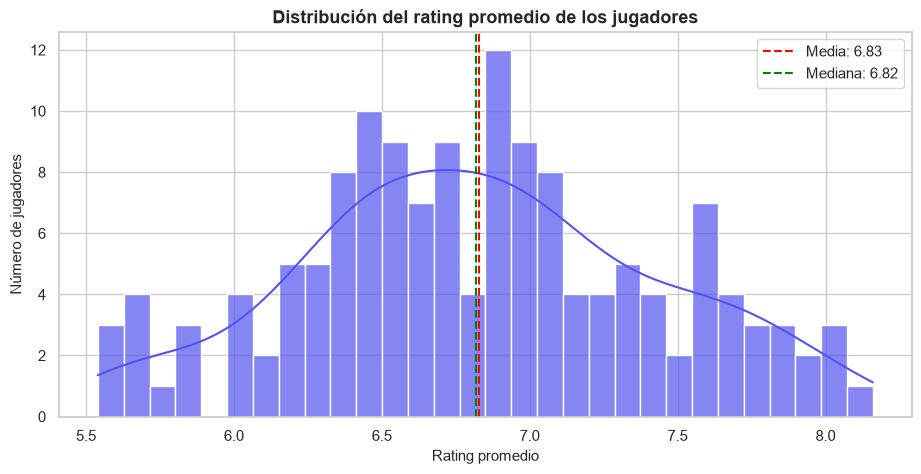

In [9]:
plt.figure(figsize=(11, 5))
sns.histplot(data=df, x="Rating_Promedio", bins=30, kde=True, color="#5353EE", alpha=0.7)
plt.title("Distribución del rating promedio de los jugadores")
plt.xlabel("Rating promedio")
plt.ylabel("Número de jugadores")
plt.axvline(df["Rating_Promedio"].mean(), color="red", linestyle="--", label=f"Media: {df['Rating_Promedio'].mean():.2f}")
plt.axvline(df["Rating_Promedio"].median(), color="green", linestyle="--", label=f"Mediana: {df['Rating_Promedio'].median():.2f}")
plt.legend()
plt.show()

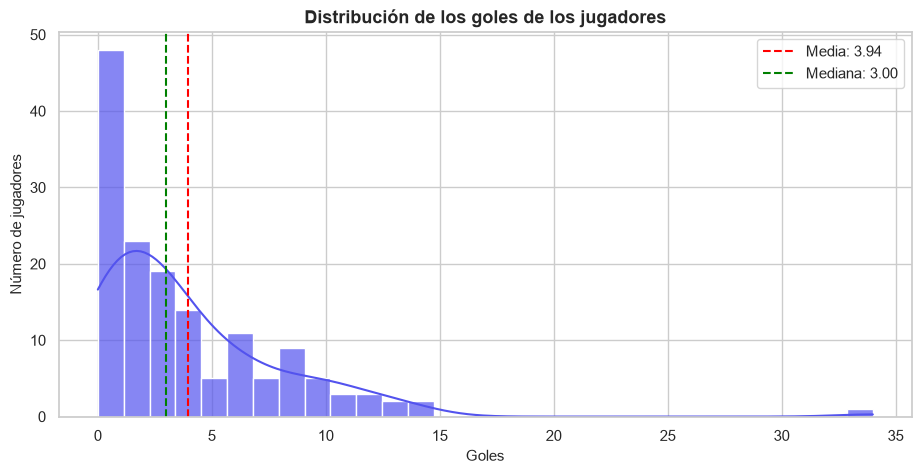

In [12]:


plt.figure(figsize=(11, 5))
sns.histplot(data=df, x="Goles", bins=30, kde=True, color="#5353EE", alpha=0.7)
plt.title("Distribución de los goles de los jugadores")
plt.xlabel("Goles")
plt.ylabel("Número de jugadores")
plt.axvline(df["Goles"].mean(), color="red", linestyle="--", label=f"Media: {df['Goles'].mean():.2f}")
plt.axvline(df["Goles"].median(), color="green", linestyle="--", label=f"Mediana: {df['Goles'].median():.2f}")
plt.legend()
plt.show()

La media de los goles es de 3.94

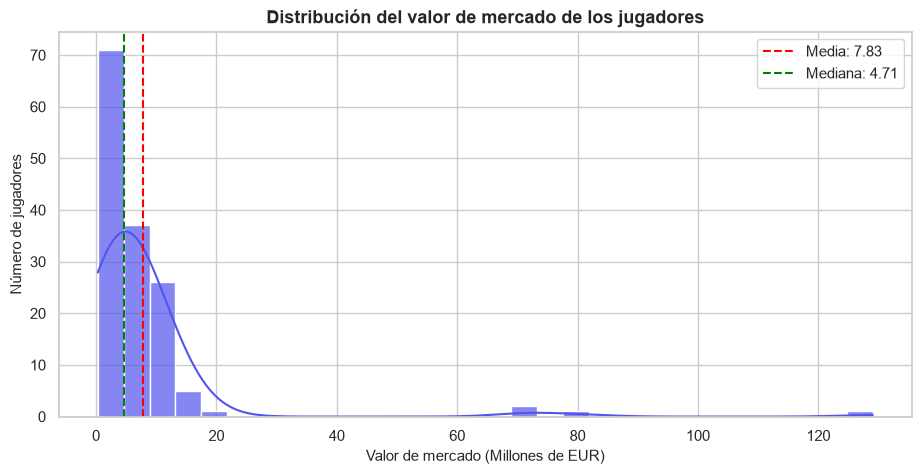

In [15]:
plt.figure(figsize=(11, 5))
sns.histplot(data=df, x="Valor_Mercado_Millones_EUR", bins=30, kde=True, color="#5353EE", alpha=0.7)
plt.title("Distribución del valor de mercado de los jugadores")
plt.xlabel("Valor de mercado (Millones de EUR)")
plt.ylabel("Número de jugadores")
plt.axvline(df["Valor_Mercado_Millones_EUR"].mean(), color="red", linestyle="--", label=f"Media: {df['Valor_Mercado_Millones_EUR'].mean():.2f}")
plt.axvline(df["Valor_Mercado_Millones_EUR"].median(), color="green", linestyle="--", label=f"Mediana: {df['Valor_Mercado_Millones_EUR'].median():.2f}")
plt.legend()
plt.show()

La mediana del valor de mercado de los jugadores es de 4.71

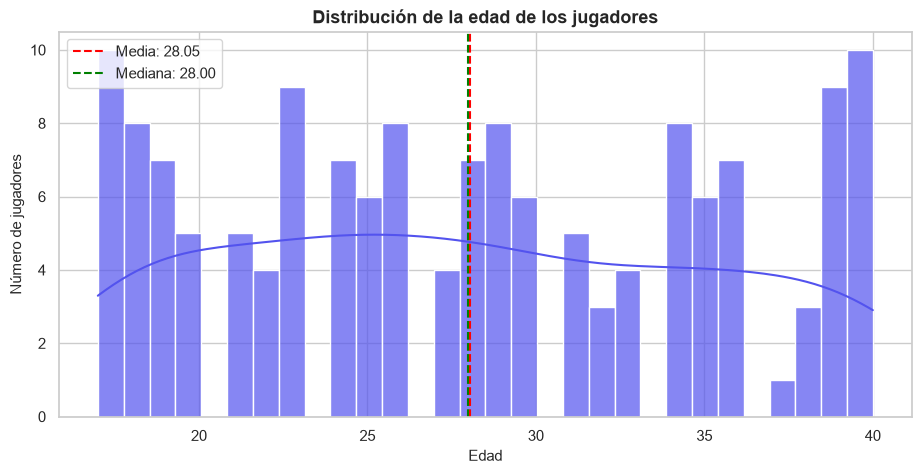

In [24]:
plt.figure(figsize=(11, 5))
sns.histplot(data=df, x="Edad", bins=30, kde=True, color="#5353EE", alpha=0.7)
plt.title("Distribución de la edad de los jugadores")
plt.xlabel("Edad")
plt.ylabel("Número de jugadores")
plt.axvline(df["Edad"].mean(), color="red", linestyle="--", label=f"Media: {df['Edad'].mean():.2f}")
plt.axvline(df["Edad"].median(), color="green", linestyle="--", label=f"Mediana: {df['Edad'].median():.2f}")
plt.legend()
plt.show()

La edad promedio de los jugadores es de 28 años

In [26]:
promedio_edad = df["Edad"].mean()

print(f"El promedio de edad de los jugadores es: {promedio_edad:.2f} años")

El promedio de edad de los jugadores es: 28.05 años


### 3.2 Múltiples distribuciones a la vez

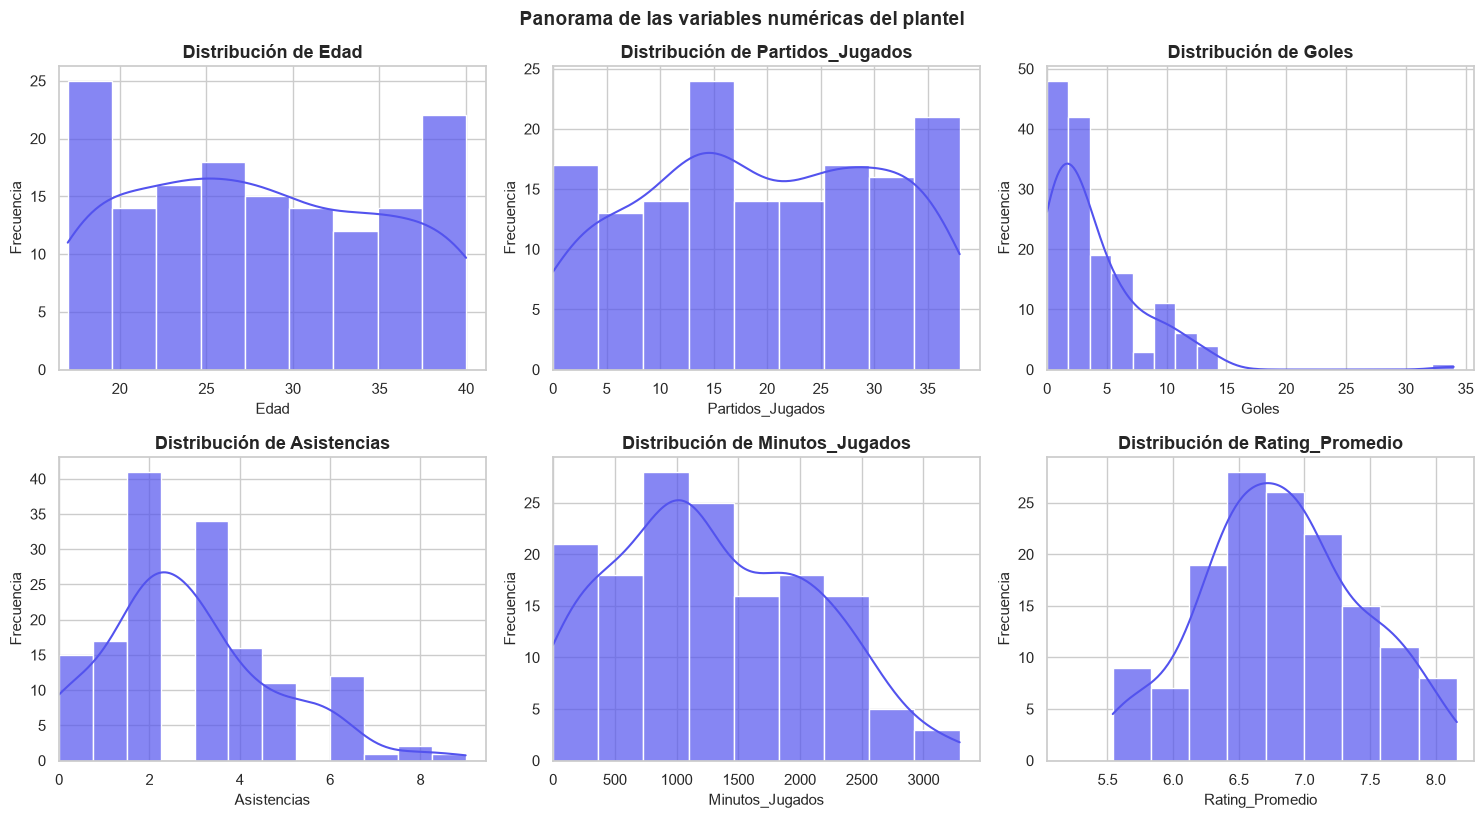

In [7]:
variables_num = [
    "Edad", "Partidos_Jugados", "Goles", "Asistencias", "Minutos_Jugados", "Rating_Promedio"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables_num):
    sns.histplot(data=df, x=var, kde=True, ax=axes[i], color="#5353EE", alpha=0.7)
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlim(left=max(0, df[var].min() - 0.5))

plt.tight_layout()
plt.suptitle("Panorama de las variables numéricas del plantel", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### 3.3 Boxplot: detectando outliers visualmente

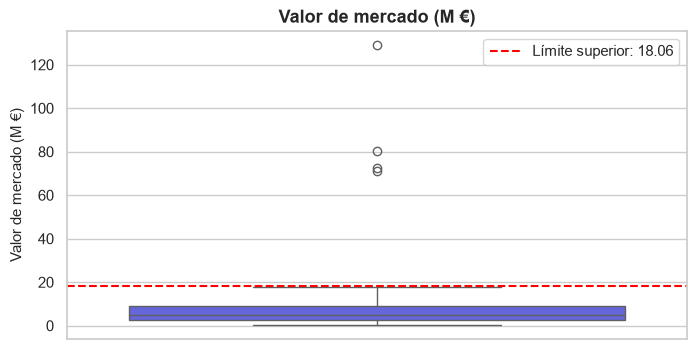

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, y="Valor_Mercado_Millones_EUR", color="#5353EE")
plt.title("Valor de mercado (M €)")
plt.ylabel("Valor de mercado (M €)")
plt.axhline(limite_superior, color="red", linestyle="--", label=f"Límite superior: {limite_superior:.2f}")
plt.legend()
plt.show()

In [19]:
Q1 = df["Valor_Mercado_Millones_EUR"].quantile(0.25)
Q3 = df["Valor_Mercado_Millones_EUR"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df[df["Valor_Mercado_Millones_EUR"] > limite_superior]

print(len(outliers))

4


4 Jugadores se consideran outliers

---
## 4. Análisis univariado categórico

Ahora nos enfocamos en variables categóricas del dataset: **posición**, **equipo** y **nacionalidad**.

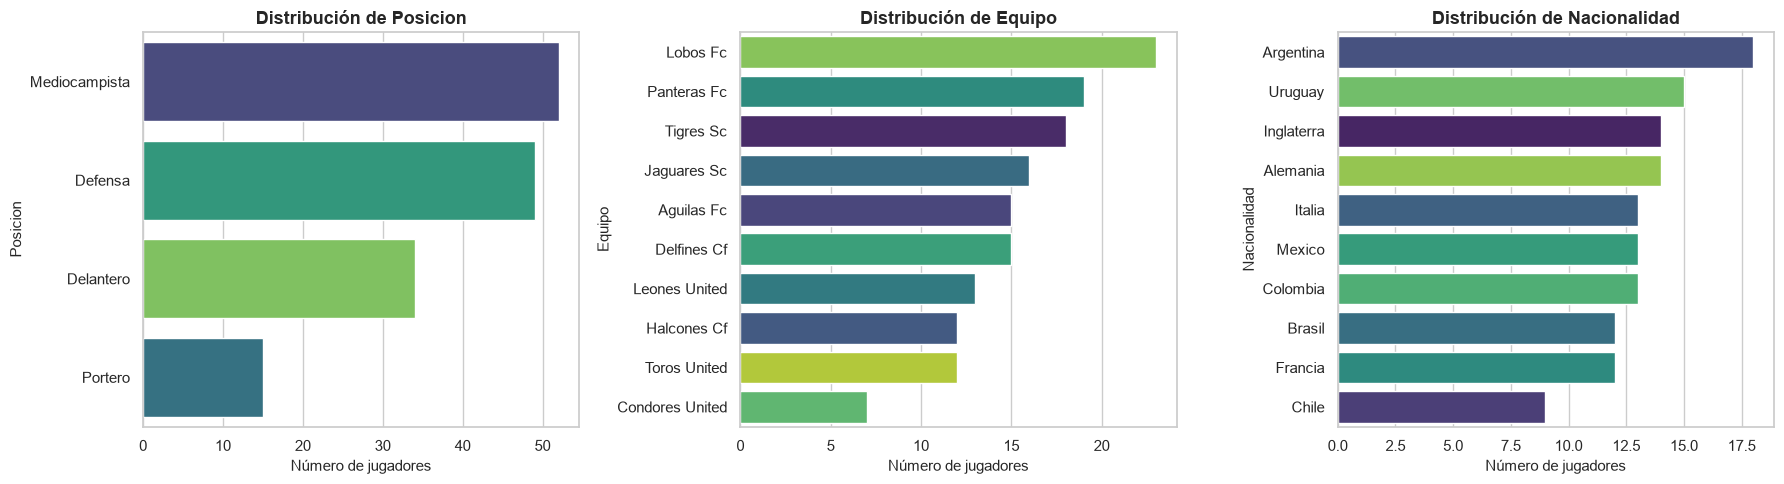

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(["Posicion", "Equipo", "Nacionalidad"]):
    orden = df[var].value_counts().head(10).index
    sns.countplot(data=df, y=var, order=orden, ax=axes[i], palette="viridis", hue=var, legend=False)
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel("Número de jugadores")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

La posición que tiene mayor cantidad de jugadores es la de mediocampista con 52

---
## 5. Análisis bivariado (categórica vs numérica)

Aquí cruzamos variables categóricas con numéricas para ver si hay diferencias claras entre posiciones o equipos.

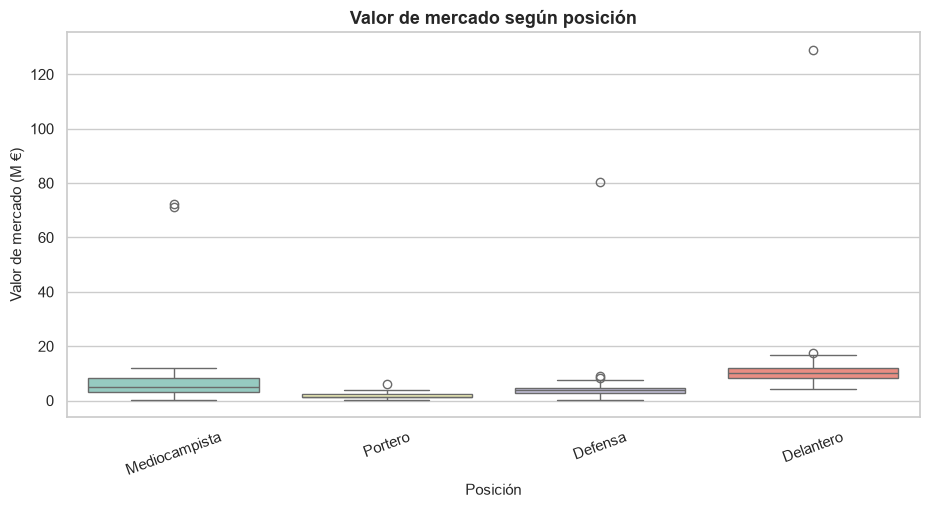

In [10]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="Posicion", y="Valor_Mercado_Millones_EUR", palette="Set3")
plt.title("Valor de mercado según posición")
plt.xlabel("Posición")
plt.ylabel("Valor de mercado (M €)")
plt.xticks(rotation=20)
plt.show()

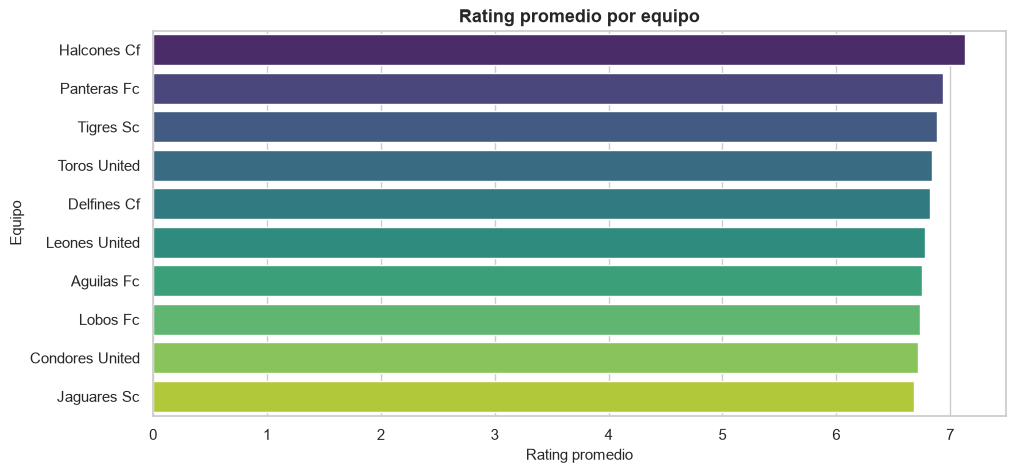

In [11]:
resumen_equipo = (
    df.groupby("Equipo")["Rating_Promedio"].mean().sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(11, 5))
sns.barplot(data=resumen_equipo, x="Rating_Promedio", y="Equipo", palette="viridis")
plt.title("Rating promedio por equipo")
plt.xlabel("Rating promedio")
plt.ylabel("Equipo")
plt.show()

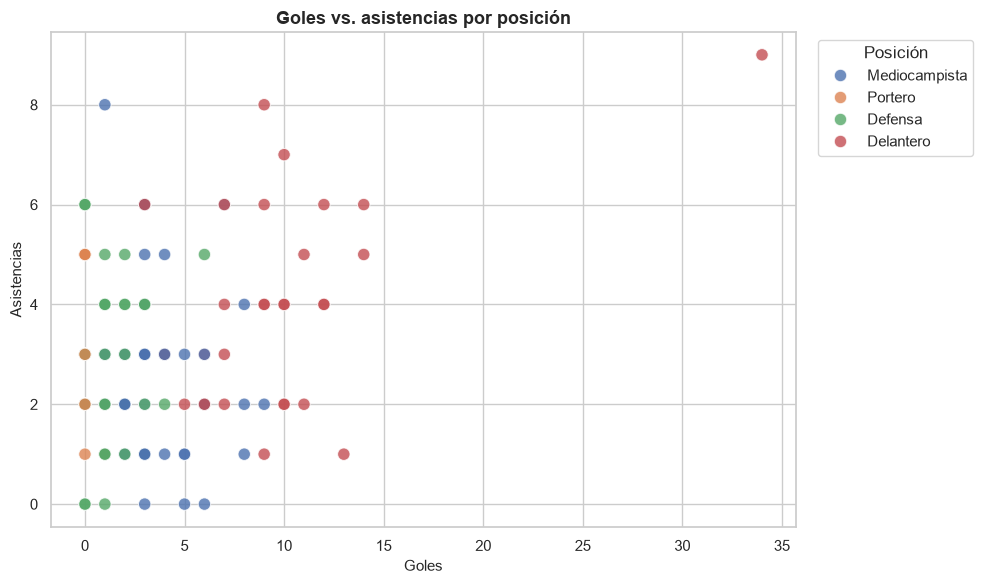

Coeficiente de correlación entre Goles y Asistencias: 0.32


In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Goles",
    y="Asistencias",
    hue="Posicion",
    alpha=0.8,
    s=80,
)
plt.title("Goles vs. asistencias por posición")
plt.xlabel("Goles")
plt.ylabel("Asistencias")
plt.legend(title="Posición", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

corr = df["Goles"].corr(df["Asistencias"])
print(f"Coeficiente de correlación entre Goles y Asistencias: {corr:.2f}")

La correlación entre goles y asistencias es positiva

---
## 6. Análisis bivariado (categórica vs categórica)

Cruzamos categorías para detectar la composición del plantel por equipo y posición.

In [ ]:
tabla = pd.crosstab(df["Posicion"], df["Equipo"])

plt.figure(figsize=(10, 5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Distribución de posiciones por equipo")
plt.xlabel("Equipo")
plt.ylabel("Posición")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
tabla_prop = pd.crosstab(df["Equipo"], df["Posicion"], normalize="index") * 100

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_prop, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "%"})
plt.title("Composición por posición dentro de cada equipo (%)")
plt.xlabel("Posición")
plt.ylabel("Equipo")
plt.xticks(rotation=25, ha="right")
plt.show()

---
## 7. Análisis multivariado y correlaciones

En esta parte buscamos relaciones entre variables con una matriz de correlación.

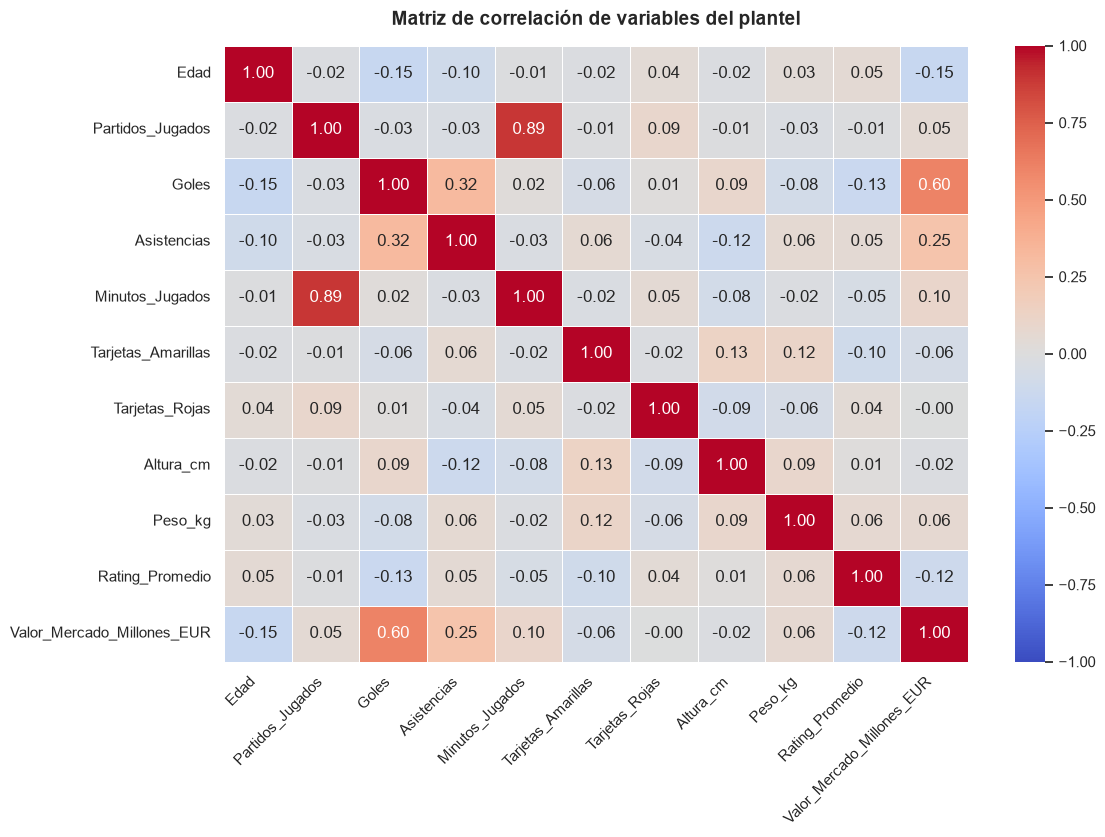

In [29]:
variables_corr = [
    "Edad", "Partidos_Jugados", "Goles", "Asistencias", "Minutos_Jugados",
    "Tarjetas_Amarillas", "Tarjetas_Rojas", "Altura_cm", "Peso_kg",
    "Rating_Promedio", "Valor_Mercado_Millones_EUR"
]

matriz = df[variables_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matriz de correlación de variables del plantel", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

---
## 8. Perfil del plantel por equipo y posición

La estructura del grupo también entrega información útil: qué equipos tienen mayor valoración, qué posiciones son mejores evaluadas y quiénes lideran el rendimiento.

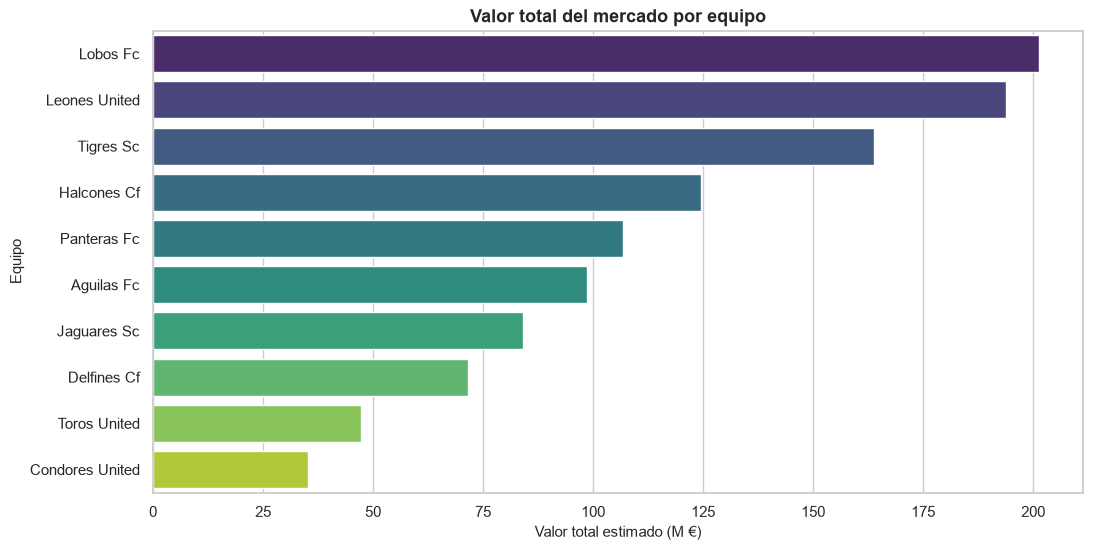

In [28]:
valor_equipo = df.groupby("Equipo")["Valor_Mercado_Millones_EUR"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=valor_equipo, x="Valor_Mercado_Millones_EUR", y="Equipo", palette="viridis")
plt.title("Valor total del mercado por equipo")
plt.xlabel("Valor total estimado (M €)")
plt.ylabel("Equipo")
plt.show()

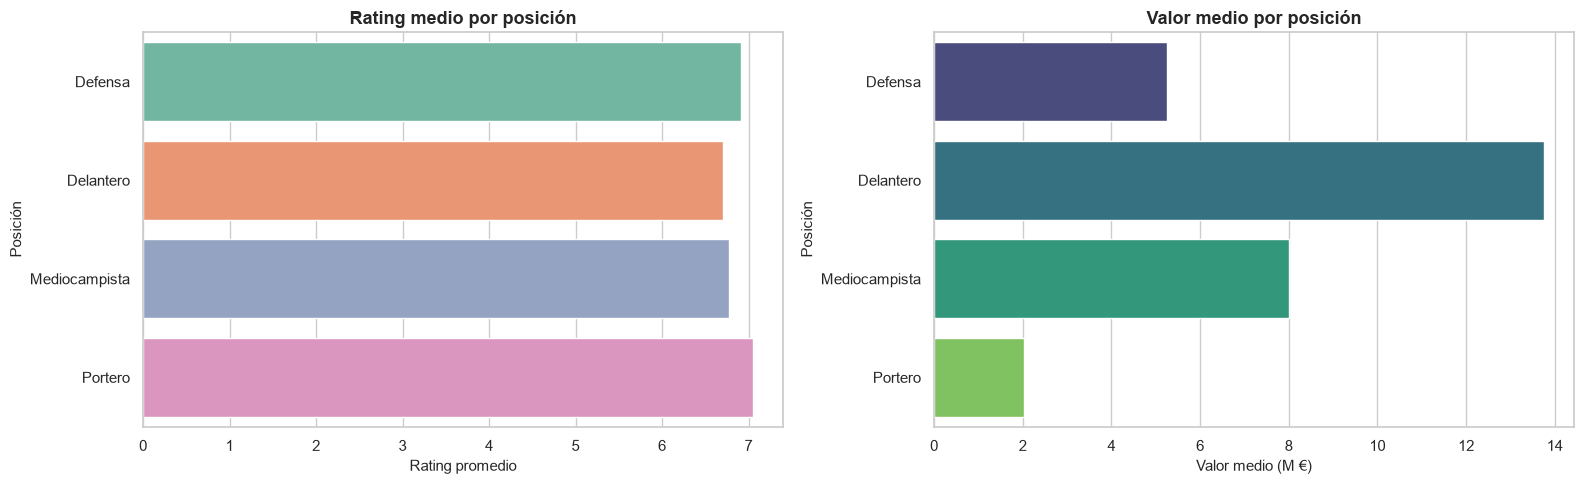

In [27]:
resumen_posicion = (
    df.groupby("Posicion")
    .agg(
        Valor_Mercado_Millones_EUR=("Valor_Mercado_Millones_EUR", "mean"),
        Rating_Promedio=("Rating_Promedio", "mean"),
        Minutos_Jugados=("Minutos_Jugados", "sum"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=resumen_posicion, x="Rating_Promedio", y="Posicion", ax=axes[0], palette="Set2")
axes[0].set_title("Rating medio por posición")
axes[0].set_xlabel("Rating promedio")
axes[0].set_ylabel("Posición")

sns.barplot(data=resumen_posicion, x="Valor_Mercado_Millones_EUR", y="Posicion", ax=axes[1], palette="viridis")
axes[1].set_title("Valor medio por posición")
axes[1].set_xlabel("Valor medio (M €)")
axes[1].set_ylabel("Posición")

plt.tight_layout()
plt.show()

---
## 9. Síntesis de hallazgos 🎯

A partir del análisis exploratorio, se observan varias tendencias importantes en el plantel:

| # | Hallazgo | Evidencia | Implicación |
|---|----------|-----------|-------------|
| 1 | El valor de mercado está concentrado en valores moderados, pero presenta varios jugadores fuera del rango habitual. | Histograma y boxplot de `Valor_Mercado_Millones_EUR` | Hay jugadores con un valor excepcional, lo que puede indicar perfiles muy destacados o casos extremos dentro del dataset. |
| 2 | La posición más frecuente es `Mediocampista`, con 52 jugadores. | Conteo de frecuencias por `Posicion` | El plantel está muy orientado a la creación y al control del juego. |
| 3 | Existe una relación positiva entre goles y asistencias. | Scatter plot de `Goles` vs `Asistencias` y coeficiente de correlación | Los jugadores más ofensivos suelen combinar mejor producción goleadora y de pase final. |




### ✅ Conclusión

Se recomienda revisar a los jugadores que tienen un valor de mercado extremo y evaluar si ese valor corresponde con su impacto real en el campo. Además, la relación entre goles y asistencias puede utilizarse como criterio importante para identificar jugadores ofensivamente más completos.